### Import Statements

In [11]:
import os
import mne
import numpy as np
import pandas as pd
import pyecap
from flexNIRs.fnirs_functions import *

import matplotlib.pyplot as plt
import h5py
import mne
import mne.channels
import mne.io.snirf
import mne_nirs.experimental_design
import mne_nirs.statistics
import seaborn as sns

from kernel_functions import *

In [63]:
meta_index = 3
snirf_type = 'hb'  #Either 'gates','moments', or 'hb'

path = r'D:\Data\Kernel\20260327_Kernel_QC\\'

metaDF = pd.read_excel(path + 'metadata.xlsx')
#tank = path + r'\\Tanks\\' + metaDF.at[meta_index, 'Tank']
kd = kernel(path, metaDF.at[meta_index, 'Kernel Hash'], snirf_type)
kd.fir_filter()

Loading D:\Data\Kernel\20260327_Kernel_QC\SNIRF\study-uwqctesting_sub-kc_desc-6599a2a_HB.snirf
Found jitter of 0.000047% in sample times.
Reading 0 ... 1590  =      0.000 ...   422.940 secs...


### Plotting

Plots of interest:
- Moments
    - Moment 2 across all modules with individual trace per SDS distance
        - solid lines = HbO, dashed lines = HbR
    - Same as above with short SDS regressed out of long SDS
- Hb Moments
    - HbT plots (with HbO and HbR as background traces) - According to kernel docs the Hb Moments already accounts for short-channel regression

In [ ]:
"""Moment Pipeline Plotting
Single module
"""
module = 1
moment = 2

modDF = kd.channelDF.loc[ (kd.channelDF['Classifier'] == 'moment' + str(moment)) & (kd.channelDF['Module'] == module)].copy()
sdsLIST = list(modDF['SDS'].unique())
wvLIST = list(modDF['Wavelength'].unique())

fig,ax = plt.subplots(figsize=(25,7.5))
ax2 = ax.twinx()

for sds in sdsLIST:

    plotDF = modDF.loc[modDF['SDS'] == sds]

    for wv in wvLIST:
        data = kd.filt_d[plotDF.loc[plotDF['Wavelength'] == wv].index]
        avg = np.mean(data, axis=0)
        if wv == 753:
            ax.plot(kd.time, avg, label = str(sds))
        elif wv == 905:
            ax2.plot(kd.time, avg, linestyle = 'dashed', label = str(sds))

for stim in kd.stim_times:
    ax.axvspan(xmin = stim[0], xmax = stim[1], color = 'gray', alpha = 0.25)

ax.legend()

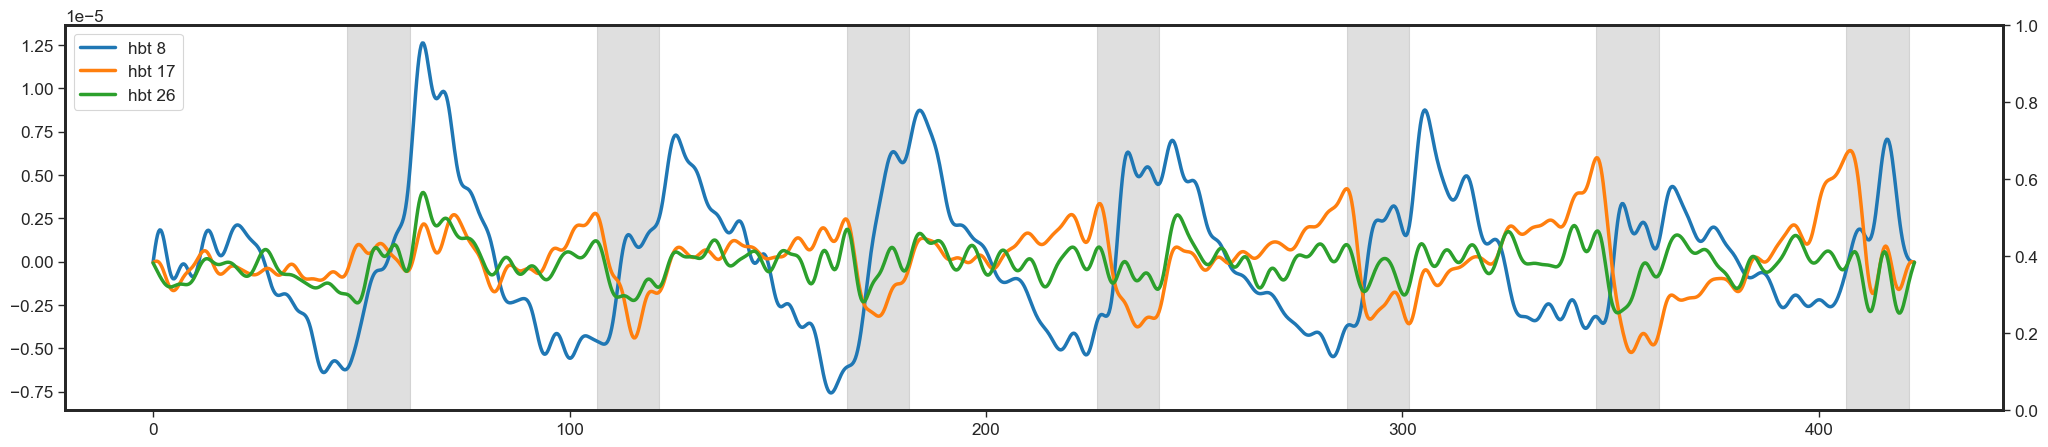

In [64]:
"""Moment Pipeline Plotting
Single module
"""
module = 1
moment = 2

modDF = kd.channelDF.loc[ kd.channelDF['Module'] == module].copy()
sdsLIST = list(modDF['SDS'].unique())
wvLIST = ['hbt']#list(modDF['Wavelength'].unique())

fig,ax = plt.subplots(figsize=(25,5))
ax2 = ax.twinx()

for sds in sdsLIST:

    plotDF = modDF.loc[modDF['SDS'] == sds]

    for wv in wvLIST:
        data = kd.filt_d[plotDF.loc[plotDF['Wavelength'] == wv].index]
        avg = np.mean(data, axis=0)
        ax.plot(kd.time, avg, label = wv + ' ' + str(sds))
        #if wv == 753:
        #    ax.plot(kd.time, avg, label = str(sds))
        #elif wv == 905:
        #    ax2.plot(kd.time, avg, linestyle = 'dashed', label = str(sds))

for stim in kd.stim_times:
    ax.axvspan(xmin = stim[0], xmax = stim[1], color = 'gray', alpha = 0.25)

ax.legend()

In [49]:
"""Hb Moment Plots"""
#df = kd.channelDF.copy()
plotDF = df.loc[ (df['Module'] == 1) & (df['SDS'] == 8) & (df['Wavelength'] == 753) & (df['Classifier'] == 'moment2')]
#plotDF
data = kd.filt_d[plotDF.index]
avg = np.mean(data, axis=0)

fig,ax = plt.subplots(figsize=(25,5))
for idx, d in enumerate(data):
    ax.plot(kd.time,d, label = idx, alpha = 0.25)
ax.plot(kd.time,avg, label = 'mean', color = 'k')

for stim in kd.stim_times:
    ax.axvspan(xmin = stim[0], xmax = stim[1], color = 'gray', alpha = 0.25)

ax.legend()

NameError: name 'df' is not defined

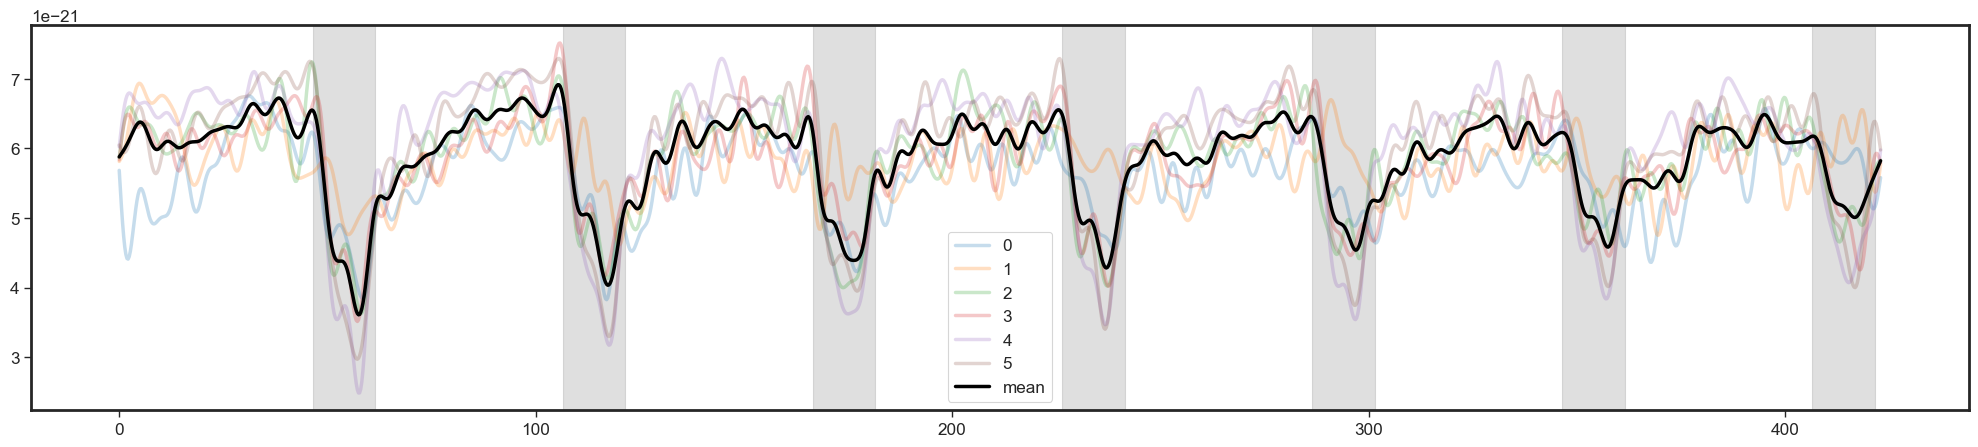

In [172]:
"""Hb Moment Plots"""
#df = kd.channelDF.copy()
plotDF = df.loc[ (df['Module'] == 1) & (df['SDS'] == 26) & (df['Wavelength'] == 753) & (df['Classifier'] == 'moment2')]
#plotDF
data = kd.filt_d[plotDF.index]
avg = np.mean(data, axis=0)

fig,ax = plt.subplots(figsize=(25,5))
for idx, d in enumerate(data):
    ax.plot(kd.time,d, label = idx, alpha = 0.25)
ax.plot(kd.time,avg, label = 'mean', color = 'k')

for stim in kd.stim_times:
    ax.axvspan(xmin = stim[0], xmax = stim[1], color = 'gray', alpha = 0.25)

ax.legend()